## Prerequisites
#### Split the `data` folder into `train` and `test` and save it to the **`dataset`** folder.

In [1]:
import os
os.getcwd()

'/Users/samyamoyrakshit/Documents/Replicating-Papers-On-CustomData/ViT'

In [2]:
from utils.split_dataset import DatasetSplitter

splitter = DatasetSplitter(source_dir="../data", target_base="../dataset", split_ratio=0.8)
splitter.split()

Rasmancha Final: Found 194 valid images.
Rasmancha Final: train = 155, test = 39, total = 194
Kalachand Temple Final: Found 126 valid images.
Kalachand Temple Final: train = 100, test = 26, total = 126
Radha Madhab Temple Final: Found 139 valid images.
Radha Madhab Temple Final: train = 111, test = 28, total = 139
Nandalal Temple Final: Found 142 valid images.
Nandalal Temple Final: train = 113, test = 29, total = 142
Radha Shyam Temple Final: Found 182 valid images.
Radha Shyam Temple Final: train = 145, test = 37, total = 182
Radha Gobinda Temple Final: Found 149 valid images.
Radha Gobinda Temple Final: train = 119, test = 30, total = 149
Shyam Rai Temple Final: Found 316 valid images.
Shyam Rai Temple Final: train = 252, test = 64, total = 316
Madan Mohan Temple Final: Found 167 valid images.
Madan Mohan Temple Final: train = 133, test = 34, total = 167
Jor Bangla Temple Final: Found 308 valid images.
Jor Bangla Temple Final: train = 246, test = 62, total = 308
Jor Mandir Final: Fo

## 0. Get setup

In [1]:
import torch
import torchvision

import matplotlib.pyplot as plt
from pathlib import Path

from torch import nn
from torchvision import transforms

import torchinfo

from utils import data_setup, engine
from utils.helper_functions import set_seeds, plot_loss_curves

In [9]:
# Setup device agnostic code
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

## 1. Get `train` and `test` path

In [11]:
image_path = Path("../dataset")
train_dir = image_path/"train"
test_dir = image_path/"test"

In [12]:
train_dir, test_dir

(PosixPath('../dataset/train'), PosixPath('../dataset/test'))

## 2. Create Datasets and DataLoaders
In Table 3, the training resolution is mentioned as being 224 (height=224, width=224).

<!-- <img src="./markdown_images/table_3.png" width="900" alt="Table 3 from the Vision Transformer paper showing the image size and batch size"/> -->

![Table 3 from the Vision Transformer paper showing the image size and batch size](./markdown_images/table_3.png)

### 2.1 Prepare transforms for images

In [13]:
# Create image size
IMG_SIZE = 224 # comes from Table 3 of ViT paper

# Create a transforms pipeline
manual_transform = transforms.Compose([
    transforms.Resize(size=(IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])
print(f"Manually created transforms: {manual_transform}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Turn images into `DataLoader`'s

In [14]:
# Create a batch size of 32 (the paper uses 4096 as batch_size but this may be too big for our smaller hardware... can always scale up later)
BATCH_SIZE = 32

# Create Dataloaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transform,
    batch_size=BATCH_SIZE,
    num_workers=2
)
len(train_dataloader), len(test_dataloader), class_names

(49,
 13,
 ['Jor Bangla Temple Final',
  'Jor Mandir Final',
  'Kalachand Temple Final',
  'Madan Mohan Temple Final',
  'Nandalal Temple Final',
  'Radha Gobinda Temple Final',
  'Radha Madhab Temple Final',
  'Radha Shyam Temple Final',
  'Rasmancha Final',
  'Shyam Rai Temple Final'])

### 2.3 Visualize a Single image

In [24]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))
print(f"image_batch shape: {image_batch.shape}") 
print(f"length of label batch: {len(label_batch)}")

# Get a single image and label from the batch
image, label = image_batch[0], label_batch[0]

# View single image and label shapes
image.shape, label

image_batch shape: torch.Size([32, 3, 224, 224])
length of label batch: 32


(torch.Size([3, 224, 224]), tensor(1))

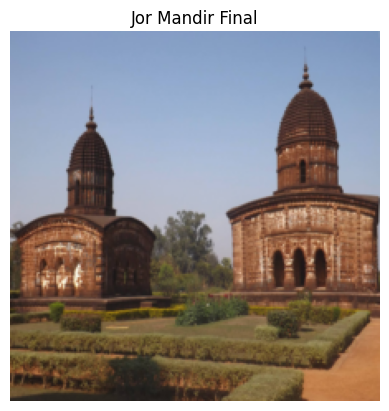

In [25]:
# Plot the image with matplotlib
plt.imshow(image.permute(1,2,0)) # (C,H,W) => (H,W,C)
plt.title(class_names[label])
plt.axis(False);